In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Colab_Dataset/bengali_ hate_v1.0.xlsx')
df.head(10)

,text,label
0,খানকির পোলা রোহিঙ্গারা বাংলাদেশে ঢুকলে কি তোর ...,Gender abusive
1,মেয়েরা বেকুবই হয় নতুন কিছু না হা হা হা,Gender abusive
2,এমন একটা পাইলে এক কম করে হলেও এক রাতে চারটি সট...,Gender abusive
3,পুরা বেশ্যা মাগী,Gender abusive
4,ঐ খানকির বাচ্চা সময় টিভি তোদের কে জুতা পিটা কর...,Gender abusive
5,মাগি যা দুধ রে সব খুল,Gender abusive
6,খানকি মাগি পো রাজনিতি বোজনা সালা হিলারি যগ্য ...,Gender abusive
7,এই খানকি তুই একটা বাসটেট,Gender abusive
8,তরে কত মানুষ গুয়া মারছে তা টিক নাই দুধ দেখলে ...,Gender abusive
9,আপনাদের মত মেয়ে দের জুতা মারা দরকার,Gender abusive


In [ ]:
df.shape

(3418, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3418 entries, 0 to 3417
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    3418 non-null   object
 1   label   3418 non-null   object
dtypes: object(2)
memory usage: 53.5+ KB


In [ ]:
df.describe()

,text,label
count,3418,3418
unique,3185,5
top,এই কাংকির ছেলে রাজাকার সবাই তো কুত্তালীগ করে এ...,Geopolitical
freq,8,1379


In [ ]:
df.isnull().sum()

,0
text,0
label,0


In [ ]:
df["label"].unique()

array(['Gender abusive', 'Geopolitical', 'Personal', 'Political',
       'Religious'], dtype=object)

In [ ]:
df["label"].value_counts()

,count
label,
Geopolitical,1379
Personal,629
Political,592
Religious,502
Gender abusive,316


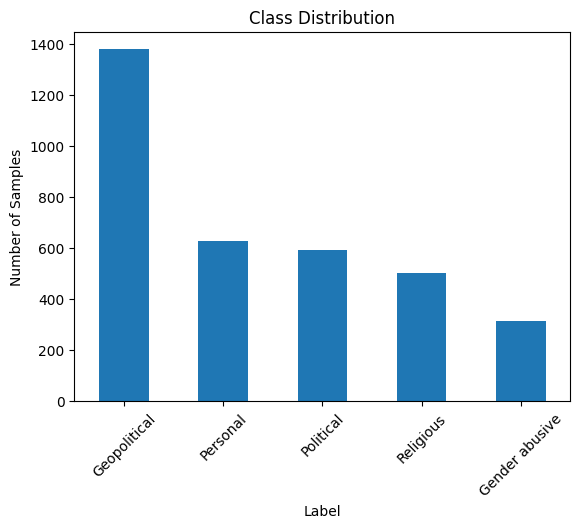

In [ ]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.xlabel("Label")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")

plt.xticks(rotation=45)

plt.show()

In [ ]:
df.duplicated().sum()

np.int64(123)

In [ ]:
df = df.drop_duplicates(subset=["text", "label"])

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
!pip install --no-cache-dir bnlp_toolkit bangla-stemmer beautifulsoup4 emoji scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 217.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 188.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 208.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 195.2 MB/s eta 0:00:00


In [ ]:
import re
import numpy as np
import emoji
from bs4 import BeautifulSoup
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from bnlp import NLTKTokenizer

nltk.download('punkt')
nltk.download('punkt_tab')
tokenizer = NLTKTokenizer()

punkt not found. downloading...


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
BANGLA_STOPWORDS = set([
    "এবং", "ও", "অথবা", "কিন্তু", "যে", "সে", "তার", "তিনি", "তারা", "তাদের",
    "এই", "ঐ", "যা", "তা", "কে", "কাকে", "কি", "কী", "কখন", "কোথায়", "কেন",
    "হয়", "হচ্ছে", "ছিল", "হবে", "করছে", "করেছে", "করবে", "একটি", "একটা",
    "জন", "টি", "টা", "জন্য", "থেকে", "দ্বারা", "দিয়ে", "পর", "অবশ্যই", "আজ"
])

In [ ]:
BANGLA_SUFFIXES = ['দের', 'দেরকে', 'দেরকে', 'গুলো', 'গুলোর', 'গুলোকে', 'টা', 'টি', 'খানা', 'খানি', 'র', 'ের', 'কে', 'তে', 'ে', 'েন', 'ছিলেন']

# 1. TOKENIZATION

In [ ]:
def tokenize_text(text):
    try:
        return tokenizer.word_tokenize(text)
    except:
        return text.split()

#3.REMOVAL OF STOPWORDS

In [ ]:
def remove_stopwords(tokens):
    return [t for t in tokens if t not in BANGLA_STOPWORDS]

# 4) & 6) TEXT STEMMING / LEMMATIZATION (Rule-Based Suffix Stripper)

In [ ]:
def stem_tokens(tokens):
    stemmed = []
    for token in tokens:
        word = token
        for suffix in sorted(BANGLA_SUFFIXES, key=len, reverse=True):
            if word.endswith(suffix) and len(word) > len(suffix) + 1:
                word = word[:-len(suffix)]
                break
        stemmed.append(word)
    return stemmed

# 7) REMOVAL OF HTML TAGS

In [ ]:
def remove_html_tags(text):
    if not isinstance(text, str): return ""
    return BeautifulSoup(text, "html.parser").get_text()

# 8) REMOVAL OF URL TAGS

In [ ]:
def remove_urls(text):
    return re.sub(r'https?://\S+|www\.\S+|ftp://\S+', '', text)

# 9) REMOVAL OF EMOTICONS & EMOJIS

In [ ]:
def remove_emoticons(text):
    return emoji.replace_emoji(text, replace='')

# 10) REMOVAL OF PUNCTUATIONS

In [ ]:
def remove_punctuations(text):
    import string
    bangla_punctuations = "।'\"’‘”“,;:!?()[]{}-–—..."
    return text.translate(str.maketrans('', '', string.punctuation + bangla_punctuations))

# 11) REMOVAL OF SPECIAL CHARACTERS

In [ ]:
def remove_special_characters(text):
    cleaned = re.sub(r'[^\u0980-\u09FF\s]', '', text)
    return re.sub(r'\s+', ' ', cleaned).strip()

#Apply function 7 to 11

In [ ]:
def apply_fun(text):
    text = remove_html_tags(text)
    text = remove_urls(text)
    text = remove_emoticons(text)
    text = remove_punctuations(text)
    text = remove_special_characters(text)
    return text

#Preprocessing start

In [ ]:
def preprocess_bangla_pipeline(text):
    if not isinstance(text, str): return ""
    cleaned = apply_fun(text)
    tokens = tokenize_text(cleaned)
    filtered = remove_stopwords(tokens)
    stemmed = stem_tokens(filtered)
    return " ".join(stemmed)

In [ ]:
text_column = 'text'

In [ ]:
df['cleaned_text'] = df[text_column].astype(str).apply(preprocess_bangla_pipeline)

#compare before and after preprocessing


In [ ]:
for index, row in df.head(5).iterrows():
    print(f"--- Sample {index + 1} ---")
    print(f"BEFORE: {row[text_column]}")
    print(f"AFTER : {row['cleaned_text']}\n")

--- Sample 1 ---
BEFORE: খানকির পোলা রোহিঙ্গারা বাংলাদেশে ঢুকলে কি তোর কোন সমস্যা 
AFTER : খানকি পোলা রোহিঙ্গারা বাংলাদেশ ঢুকল তো কোন সমস্যা

--- Sample 2 ---
BEFORE: মেয়েরা বেকুবই হয় নতুন কিছু না হা হা হা
AFTER : মেয়েরা বেকুবই নতুন কিছু না হা হা হা

--- Sample 3 ---
BEFORE: এমন একটা পাইলে এক কম করে হলেও এক রাতে চারটি সট দিতাম 
AFTER : এমন পাইল এক কম কর হলেও এক রা চার সট দিতাম

--- Sample 4 ---
BEFORE: পুরা বেশ্যা মাগী 
AFTER : পুরা বেশ্যা মাগী

--- Sample 5 ---
BEFORE: ঐ খানকির বাচ্চা সময় টিভি তোদের কে জুতা পিটা করব এরা অসহায় মানুষ এদের নিউজ তৈরী করতে রাত জাগস অথচ ভারতের অবৈধভাবে এনে এই দেশে পুলিশের চাকরি দিছে সেই নিউজ কই ভালো হয়ে যা
AFTER : খানকি বাচ্চা সময় টিভি তো জুতা পি করব এরা অসহায় মানুষ এদ নিউজ তৈরী কর রাত জাগস অথচ ভারত অবৈধভাব এন দেশ পুলিশ চাকরি দিছ সেই নিউজ কই ভালো হয়

